In [13]:
#crispr_carT_AI_analysis/
 #   analysis_utils/
  #      pca_utils.py
   #     preprocessing.py
    #    config_utils.py
   # data/
   # results/
       # pca/

In [3]:
import os, sys, importlib

# 1. Make sure we're in the project root
PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)
print("CWD:", os.getcwd())

# 2. Force Python to look at this project first
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("First sys.path entry:", sys.path[0])

# 3. Import and reload pca_utils from THIS project
import analysis_utils.pca_utils as pca_utils
importlib.reload(pca_utils)

from analysis_utils.pca_utils import run_pca_and_save


CWD: /Users/acastano/Desktop/crispr_carT_AI_analysis
First sys.path entry: /Users/acastano/Desktop/crispr_carT_AI_analysis


In [4]:
import importlib
import analysis_utils.pca_utils
importlib.reload(analysis_utils.pca_utils)

from analysis_utils.pca_utils import run_pca_and_save


In [5]:
import os, sys

project_root = os.path.expanduser("~/Desktop/crispr_carT_AI_analysis")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from analysis_utils.config_utils import load_config
print("load_config:", load_config)


ImportError: cannot import name 'load_config' from 'analysis_utils.config_utils' (/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/config_utils.py)

In [6]:
import os, sys

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from analysis_utils.pca_utils import run_pca_and_save
import pandas as pd


In [7]:
expr_logcpm = pd.read_csv("results/preprocessing/expr_logcpm.csv", index_col=0)

scores_df, loadings_df, explained_df, pca_obj = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    random_state=0,
    assign_quadrants=True,
    quadrant_pcs=("PC1", "PC2"),
)


In [8]:
from pathlib import Path
import sys

project_root = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()

# Make sure the root is on sys.path as a *string*
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("sys.path contains project_root:", str(project_root) in sys.path)

# Test importing the package itself
import analysis_utils
print("analysis_utils module loaded from:", analysis_utils.__file__)


sys.path contains project_root: True
analysis_utils module loaded from: /Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/__init__.py


In [9]:
scores_df, loadings_df, explained_df, _ = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    random_state=0,
    assign_quadrants=True,
    quadrant_pcs=("PC1", "PC2"),
)



In [10]:
import os, sys, pandas as pd

PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
os.chdir(PROJECT_ROOT)

# Ensure project root is on sys.path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from analysis_utils.pca_utils import run_pca_and_save

# Load expression
expr_logcpm = pd.read_csv("results/preprocessing/expr_logcpm.csv", index_col=0)

# Run PCA (safe to re-run; it will just overwrite the same CSVs)
scores_df, loadings_df, explained_df = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    random_state=0,
    assign_quadrants=True,
    quadrant_pcs=("PC1", "PC2"),
)

scores_df.shape, loadings_df.shape, explained_df.shape


ValueError: too many values to unpack (expected 3)

In [ ]:
explained_df


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(explained_df["PC"], explained_df["explained_variance_ratio"])
plt.xticks(rotation=45)
plt.ylabel("Explained variance ratio")
plt.title("PCA variance explained")
plt.tight_layout()
plt.show()


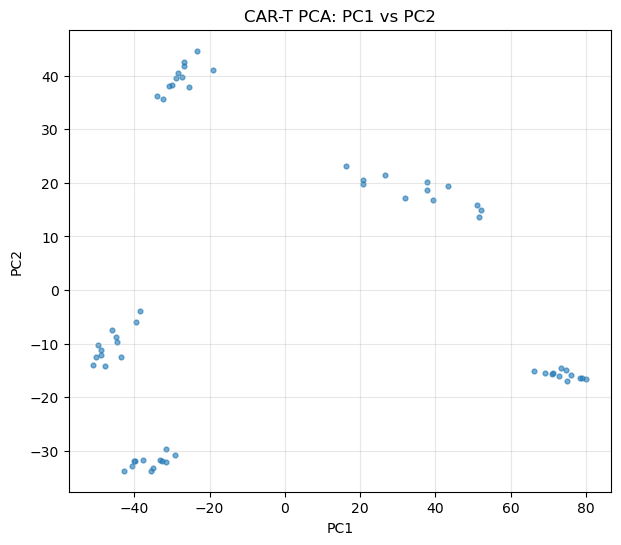

In [11]:
plt.figure(figsize=(7,6))
plt.scatter(scores_df["PC1"], scores_df["PC2"], s=12, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CAR-T PCA: PC1 vs PC2")
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
scores_df["quadrant_PC1_PC2"].value_counts()


quadrant_PC1_PC2
Q3    24
Q4    12
Q1    12
Q2    12
Name: count, dtype: int64

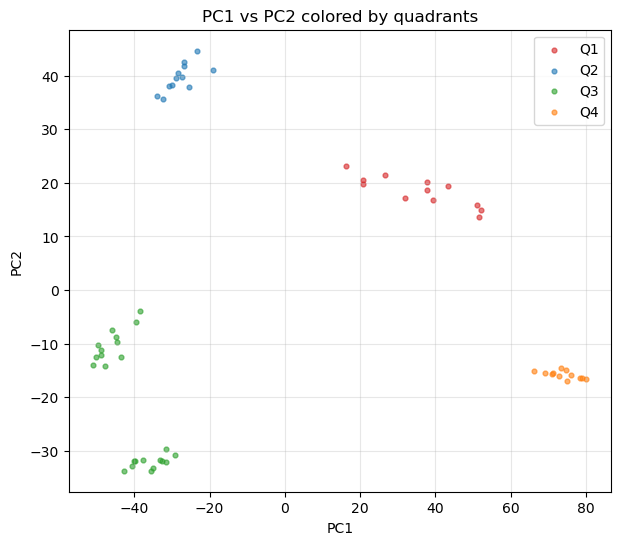

In [13]:
import matplotlib.pyplot as plt

colors = {
    "Q1": "tab:red",
    "Q2": "tab:blue",
    "Q3": "tab:green",
    "Q4": "tab:orange",
}

plt.figure(figsize=(7,6))
for quad, sub in scores_df.groupby("quadrant_PC1_PC2"):
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        s=12,
        alpha=0.6,
        label=quad,
        c=colors.get(quad, "grey"),
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by quadrants")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
def top_genes(loadings_df, pc, n=20):
    return loadings_df[pc].sort_values(ascending=False).head(n)

def bottom_genes(loadings_df, pc, n=20):
    return loadings_df[pc].sort_values(ascending=True).head(n)

top_pc1 = top_genes(loadings_df, "PC1", 20)
top_pc2 = top_genes(loadings_df, "PC2", 20)
bot_pc1 = bottom_genes(loadings_df, "PC1", 20)
bot_pc2 = bottom_genes(loadings_df, "PC2", 20)

top_pc1, top_pc2


(gene
 ENSG00000164399    0.065809
 ENSG00000185686    0.057727
 ENSG00000177455    0.055486
 ENSG00000204671    0.049034
 ENSG00000179348    0.047174
 ENSG00000111537    0.047119
 ENSG00000164400    0.046530
 ENSG00000142949    0.046507
 ENSG00000185215    0.046306
 ENSG00000169429    0.045154
 ENSG00000088882    0.044586
 ENSG00000137285    0.044208
 ENSG00000168334    0.043940
 ENSG00000169245    0.043729
 ENSG00000102962    0.043620
 ENSG00000109471    0.043184
 ENSG00000132688    0.042548
 ENSG00000204291    0.041817
 ENSG00000108691    0.040612
 ENSG00000143185    0.040279
 Name: PC1, dtype: float64,
 gene
 ENSG00000004468    0.056267
 ENSG00000117318    0.051999
 ENSG00000130595    0.051463
 ENSG00000066056    0.046911
 ENSG00000102962    0.046700
 ENSG00000205593    0.045109
 ENSG00000123689    0.044409
 ENSG00000116016    0.044404
 ENSG00000115523    0.042663
 ENSG00000217482    0.041878
 ENSG00000275410    0.040652
 ENSG00000168477    0.038606
 ENSG00000164949    0.038254
 EN

In [15]:
loadings_df["quadrant_PC1_PC2"].value_counts()


quadrant_PC1_PC2
Q1    25938
Q4    13589
Q3    12145
Q2     9003
Name: count, dtype: int64

In [16]:
genes_q1 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q1"].index.tolist()
genes_q1[:30]


['ENSG00000284332',
 'ENSG00000237613',
 'ENSG00000268020',
 'ENSG00000269981',
 'ENSG00000222623',
 'ENSG00000286448',
 'ENSG00000236679',
 'ENSG00000236601',
 'ENSG00000237094',
 'ENSG00000278757',
 'ENSG00000235146',
 'ENSG00000225630',
 'ENSG00000278791',
 'ENSG00000240409',
 'ENSG00000268663',
 'ENSG00000284662',
 'ENSG00000229376',
 'ENSG00000223181',
 'ENSG00000285268',
 'ENSG00000230368',
 'ENSG00000234711',
 'ENSG00000283040',
 'ENSG00000223764',
 'ENSG00000187634',
 'ENSG00000188290',
 'ENSG00000231702',
 'ENSG00000188157',
 'ENSG00000242590',
 'ENSG00000217801',
 'ENSG00000273443']

In [17]:
import pandas as pd

map_path = "data/processed/ensg_to_symbol.csv"
ensg_map = pd.read_csv(map_path)

ensg_map.head()


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [18]:
ensg_to_symbol = dict(zip(ensg_map.iloc[:,0], ensg_map.iloc[:,1]))


In [19]:
index = ENSG00000223972, ENSG00000227232, …


SyntaxError: invalid character '…' (U+2026) (2370386953.py, line 1)

In [20]:
loadings_df = loadings_df.copy()
loadings_df["gene_symbol"] = loadings_df.index.map(ensg_to_symbol).fillna(loadings_df.index)
loadings_df = loadings_df.set_index("gene_symbol")


TypeError: 'value' must be a scalar, passed: Index

In [21]:
scores_df.index = scores_df.index.map(lambda x: x)   # samples stay same
loadings_df.index = loadings_df.index.map(str)       # already converted above


In [22]:
loadings_df["PC1"].sort_values(ascending=False).head(20)


gene
ENSG00000164399    0.065809
ENSG00000185686    0.057727
ENSG00000177455    0.055486
ENSG00000204671    0.049034
ENSG00000179348    0.047174
ENSG00000111537    0.047119
ENSG00000164400    0.046530
ENSG00000142949    0.046507
ENSG00000185215    0.046306
ENSG00000169429    0.045154
ENSG00000088882    0.044586
ENSG00000137285    0.044208
ENSG00000168334    0.043940
ENSG00000169245    0.043729
ENSG00000102962    0.043620
ENSG00000109471    0.043184
ENSG00000132688    0.042548
ENSG00000204291    0.041817
ENSG00000108691    0.040612
ENSG00000143185    0.040279
Name: PC1, dtype: float64

In [23]:
import pandas as pd

map_path = "data/processed/ensg_to_symbol.csv"
ensg_map = pd.read_csv(map_path)

print(ensg_map.columns)
ensg_map.head()


Index(['ensembl', 'symbol'], dtype='object')


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [24]:
cols = [c.lower() for c in ensg_map.columns]
print("Columns (lowercased):", cols)

# Pick the ENSG/Ensembl column
ensg_col = None
for c in ensg_map.columns:
    cl = c.lower()
    if "ensg" in cl or "ensembl" in cl or "gene_id" in cl:
        ensg_col = c
        break

# Pick the symbol column
sym_col = None
for c in ensg_map.columns:
    cl = c.lower()
    if "symbol" in cl or "gene_name" in cl or (("name" in cl or "symbol" in cl) and "gene" in cl):
        sym_col = c
        break

print("Using columns:", ensg_col, "→", sym_col)


Columns (lowercased): ['ensembl', 'symbol']
Using columns: ensembl → symbol


In [25]:
def strip_version(x):
    # Turn 'ENSG00000123456.5' -> 'ENSG00000123456'
    return str(x).split(".")[0]

ensg_to_symbol = {
    strip_version(e): s
    for e, s in zip(ensg_map[ensg_col], ensg_map[sym_col])
}


In [26]:
loadings_df = loadings_df.copy()

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if missing

loadings_df["gene_symbol"] = loadings_df.index.map(map_ensg_to_symbol)
loadings_df = loadings_df.set_index("gene_symbol")


In [27]:
loadings_df.head()
loadings_df["PC1"].sort_values(ascending=False).head(20)


gene_symbol
IL3        0.065809
PRAME      0.057727
CD19       0.055486
IL31       0.049034
GATA2      0.047174
IFNG       0.047119
CSF2       0.046530
PTPRF      0.046507
TNFAIP2    0.046306
CXCL8      0.045154
CPXM1      0.044586
TUBB2B     0.044208
XIRP1      0.043940
CXCL10     0.043729
CCL22      0.043620
IL2        0.043184
NES        0.042548
COL15A1    0.041817
CCL2       0.040612
XCL2       0.040279
Name: PC1, dtype: float64

In [28]:
loadings_df["PC1"].sort_values(ascending=False).head(20)

gene_symbol
IL3        0.065809
PRAME      0.057727
CD19       0.055486
IL31       0.049034
GATA2      0.047174
IFNG       0.047119
CSF2       0.046530
PTPRF      0.046507
TNFAIP2    0.046306
CXCL8      0.045154
CPXM1      0.044586
TUBB2B     0.044208
XIRP1      0.043940
CXCL10     0.043729
CCL22      0.043620
IL2        0.043184
NES        0.042548
COL15A1    0.041817
CCL2       0.040612
XCL2       0.040279
Name: PC1, dtype: float64

In [29]:
import pandas as pd

# 1. Load mapping
map_path = "data/processed/ensg_to_symbol.csv"
ensg_map = pd.read_csv(map_path)

print("Mapping columns:", ensg_map.columns)
ensg_map.head()


Mapping columns: Index(['ensembl', 'symbol'], dtype='object')


,ensembl,symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [30]:
# Helper to strip version suffix: ENSG00000123456.5 → ENSG00000123456
def strip_version(x):
    return str(x).split(".")[0]

# Infer which columns hold ENSG IDs and symbols
ensg_col = None
sym_col = None

for c in ensg_map.columns:
    cl = c.lower()
    if any(tok in cl for tok in ["ensg", "ensembl", "gene_id"]):
        ensg_col = c
    if any(tok in cl for tok in ["symbol", "gene_name", "gene symbol"]):
        sym_col = c

print("Using mapping:", ensg_col, "→", sym_col)

ensg_to_symbol = {
    strip_version(e): s
    for e, s in zip(ensg_map[ensg_col], ensg_map[sym_col])
}
len(ensg_to_symbol)


Using mapping: ensembl → symbol


46920

In [31]:
loadings_df = loadings_df.copy()

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if not found

loadings_df["gene_symbol"] = loadings_df.index.map(map_ensg_to_symbol)
loadings_df = loadings_df.set_index("gene_symbol")

loadings_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,quadrant_PC1_PC2
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,9.366323e-05,-5.282017e-04,6.088233e-04,-3.385882e-04,1.808923e-04,4.860088e-04,-1.196203e-03,-3.756108e-05,-9.979868e-04,-5.844181e-04,...,3.536317e-03,3.163893e-04,1.667314e-03,-1.217134e-03,-2.964380e-03,6.528304e-04,-3.926019e-04,-6.542218e-04,-1.530320e-03,Q4
WASH7P,-3.324999e-03,6.731644e-04,5.108593e-03,-5.471734e-03,-5.558026e-03,9.070120e-03,-1.617013e-02,3.802345e-03,-3.546346e-03,1.064187e-02,...,-2.880367e-03,4.094618e-03,-6.011375e-04,2.309274e-03,7.012333e-03,2.365731e-03,-4.389319e-03,-5.213923e-03,1.894618e-03,Q2
MIR6859-1,-7.036649e-04,1.111626e-03,1.081793e-03,-3.061830e-03,9.131693e-05,2.191194e-03,-1.333419e-03,-2.701733e-04,-2.068966e-03,1.125666e-03,...,-2.441894e-03,-2.635515e-03,8.653626e-04,2.582577e-03,9.705423e-03,-6.766427e-03,1.576182e-03,-3.041267e-03,-1.353557e-03,Q2
MIR1302-2HG,-6.616423e-05,-1.578408e-04,1.272980e-05,3.455076e-04,2.916554e-04,5.850734e-05,1.673697e-06,4.267931e-04,8.589290e-04,-5.087637e-04,...,1.382777e-03,-1.111069e-04,2.230550e-04,1.886302e-03,-1.648261e-03,9.649164e-04,6.785596e-05,-4.186622e-04,-3.946276e-03,Q3
MIR1302-2,3.444683e-22,3.035688e-20,-6.395881e-19,3.802729e-17,2.707710e-17,-2.123324e-16,4.679518e-16,2.727930e-16,9.827153e-16,-7.346275e-15,...,-2.031949e-15,5.162920e-15,2.626342e-16,-2.274869e-15,2.652177e-15,1.151923e-15,-8.641983e-16,-3.298201e-15,-5.609388e-15,Q1


In [32]:
def top_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=False).head(n)

def bottom_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=True).head(n)

top_pc1 = top_genes(loadings_df, "PC1", 20)
top_pc2 = top_genes(loadings_df, "PC2", 20)
bot_pc1 = bottom_genes(loadings_df, "PC1", 20)
bot_pc2 = bottom_genes(loadings_df, "PC2", 20)

top_pc1, top_pc2


(gene_symbol
 IL3        0.065809
 PRAME      0.057727
 CD19       0.055486
 IL31       0.049034
 GATA2      0.047174
 IFNG       0.047119
 CSF2       0.046530
 PTPRF      0.046507
 TNFAIP2    0.046306
 CXCL8      0.045154
 CPXM1      0.044586
 TUBB2B     0.044208
 XIRP1      0.043940
 CXCL10     0.043729
 CCL22      0.043620
 IL2        0.043184
 NES        0.042548
 COL15A1    0.041817
 CCL2       0.040612
 XCL2       0.040279
 Name: PC1, dtype: float64,
 gene_symbol
 CD38               0.056267
 ID3                0.051999
 TNNT3              0.051463
 TIE1               0.046911
 CCL22              0.046700
 DENND6B            0.045109
 G0S2               0.044409
 EPAS1              0.044404
 GNLY               0.042663
 HMGB1P17           0.041878
 HNF1B              0.040652
 TNXB               0.038606
 GEM                0.038254
 METRNL             0.037657
 NR5A2              0.037455
 SERPINE2           0.036926
 NRP2               0.036548
 ENSG00000271755    0.036156
 STX

In [33]:
# Helper to strip version suffix: ENSG00000123456.5 → ENSG00000123456
def strip_version(x):
    return str(x).split(".")[0]

# Infer which columns hold ENSG IDs and symbols
ensg_col = None
sym_col = None

for c in ensg_map.columns:
    cl = c.lower()
    if any(tok in cl for tok in ["ensg", "ensembl", "gene_id"]):
        ensg_col = c
    if any(tok in cl for tok in ["symbol", "gene_name", "gene symbol"]):
        sym_col = c

print("Using mapping:", ensg_col, "→", sym_col)

ensg_to_symbol = {
    strip_version(e): s
    for e, s in zip(ensg_map[ensg_col], ensg_map[sym_col])
}
len(ensg_to_symbol)


Using mapping: ensembl → symbol


46920

In [34]:
loadings_df = loadings_df.copy()

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if not found

loadings_df["gene_symbol"] = loadings_df.index.map(map_ensg_to_symbol)
loadings_df = loadings_df.set_index("gene_symbol")

loadings_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,quadrant_PC1_PC2
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,9.366323e-05,-5.282017e-04,6.088233e-04,-3.385882e-04,1.808923e-04,4.860088e-04,-1.196203e-03,-3.756108e-05,-9.979868e-04,-5.844181e-04,...,3.536317e-03,3.163893e-04,1.667314e-03,-1.217134e-03,-2.964380e-03,6.528304e-04,-3.926019e-04,-6.542218e-04,-1.530320e-03,Q4
WASH7P,-3.324999e-03,6.731644e-04,5.108593e-03,-5.471734e-03,-5.558026e-03,9.070120e-03,-1.617013e-02,3.802345e-03,-3.546346e-03,1.064187e-02,...,-2.880367e-03,4.094618e-03,-6.011375e-04,2.309274e-03,7.012333e-03,2.365731e-03,-4.389319e-03,-5.213923e-03,1.894618e-03,Q2
MIR6859-1,-7.036649e-04,1.111626e-03,1.081793e-03,-3.061830e-03,9.131693e-05,2.191194e-03,-1.333419e-03,-2.701733e-04,-2.068966e-03,1.125666e-03,...,-2.441894e-03,-2.635515e-03,8.653626e-04,2.582577e-03,9.705423e-03,-6.766427e-03,1.576182e-03,-3.041267e-03,-1.353557e-03,Q2
MIR1302-2HG,-6.616423e-05,-1.578408e-04,1.272980e-05,3.455076e-04,2.916554e-04,5.850734e-05,1.673697e-06,4.267931e-04,8.589290e-04,-5.087637e-04,...,1.382777e-03,-1.111069e-04,2.230550e-04,1.886302e-03,-1.648261e-03,9.649164e-04,6.785596e-05,-4.186622e-04,-3.946276e-03,Q3
MIR1302-2,3.444683e-22,3.035688e-20,-6.395881e-19,3.802729e-17,2.707710e-17,-2.123324e-16,4.679518e-16,2.727930e-16,9.827153e-16,-7.346275e-15,...,-2.031949e-15,5.162920e-15,2.626342e-16,-2.274869e-15,2.652177e-15,1.151923e-15,-8.641983e-16,-3.298201e-15,-5.609388e-15,Q1


In [35]:
def top_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=False).head(n)

def bottom_genes(df, pc, n=20):
    return df[pc].sort_values(ascending=True).head(n)

top_pc1 = top_genes(loadings_df, "PC1", 20)
top_pc2 = top_genes(loadings_df, "PC2", 20)
bot_pc1 = bottom_genes(loadings_df, "PC1", 20)
bot_pc2 = bottom_genes(loadings_df, "PC2", 20)

top_pc1, top_pc2


(gene_symbol
 IL3        0.065809
 PRAME      0.057727
 CD19       0.055486
 IL31       0.049034
 GATA2      0.047174
 IFNG       0.047119
 CSF2       0.046530
 PTPRF      0.046507
 TNFAIP2    0.046306
 CXCL8      0.045154
 CPXM1      0.044586
 TUBB2B     0.044208
 XIRP1      0.043940
 CXCL10     0.043729
 CCL22      0.043620
 IL2        0.043184
 NES        0.042548
 COL15A1    0.041817
 CCL2       0.040612
 XCL2       0.040279
 Name: PC1, dtype: float64,
 gene_symbol
 CD38               0.056267
 ID3                0.051999
 TNNT3              0.051463
 TIE1               0.046911
 CCL22              0.046700
 DENND6B            0.045109
 G0S2               0.044409
 EPAS1              0.044404
 GNLY               0.042663
 HMGB1P17           0.041878
 HNF1B              0.040652
 TNXB               0.038606
 GEM                0.038254
 METRNL             0.037657
 NR5A2              0.037455
 SERPINE2           0.036926
 NRP2               0.036548
 ENSG00000271755    0.036156
 STX

In [36]:
loadings_df["quadrant_PC1_PC2"].value_counts()


quadrant_PC1_PC2
Q1    25938
Q4    13589
Q3    12145
Q2     9003
Name: count, dtype: int64

In [37]:
genes_q1 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q1"].index.tolist()
genes_q2 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q2"].index.tolist()
genes_q3 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q3"].index.tolist()
genes_q4 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q4"].index.tolist()

genes_q1[:20]


['MIR1302-2',
 'FAM138A',
 'OR4G4P',
 'ENSG00000269981',
 'RNU6-1100P',
 'ENSG00000286448',
 'RPL23AP24',
 'ENSG00000236601',
 'ENSG00000237094',
 'ENSG00000278757',
 'ENSG00000235146',
 'MTND2P28',
 'ENSG00000278791',
 'MTATP8P1',
 'WBP1LP6',
 'OR4F16',
 'CICP3',
 'RNU6-1199P',
 'ENSG00000285268',
 'FAM41C']

In [38]:
genes_q1 = loadings_df[loadings_df["quadrant_PC1_PC2"] == "Q1"].index.tolist()
genes_q1[:20]

['MIR1302-2',
 'FAM138A',
 'OR4G4P',
 'ENSG00000269981',
 'RNU6-1100P',
 'ENSG00000286448',
 'RPL23AP24',
 'ENSG00000236601',
 'ENSG00000237094',
 'ENSG00000278757',
 'ENSG00000235146',
 'MTND2P28',
 'ENSG00000278791',
 'MTATP8P1',
 'WBP1LP6',
 'OR4F16',
 'CICP3',
 'RNU6-1199P',
 'ENSG00000285268',
 'FAM41C']

In [39]:
top_pc1 = loadings_df["PC1"].sort_values(ascending=False).head(30)
bot_pc1 = loadings_df["PC1"].sort_values(ascending=True).head(30)

top_pc2 = loadings_df["PC2"].sort_values(ascending=False).head(30)
bot_pc2 = loadings_df["PC2"].sort_values(ascending=True).head(30)

top_pc1, top_pc2


(gene_symbol
 IL3        0.065809
 PRAME      0.057727
 CD19       0.055486
 IL31       0.049034
 GATA2      0.047174
 IFNG       0.047119
 CSF2       0.046530
 PTPRF      0.046507
 TNFAIP2    0.046306
 CXCL8      0.045154
 CPXM1      0.044586
 TUBB2B     0.044208
 XIRP1      0.043940
 CXCL10     0.043729
 CCL22      0.043620
 IL2        0.043184
 NES        0.042548
 COL15A1    0.041817
 CCL2       0.040612
 XCL2       0.040279
 CD24       0.039944
 IGF2BP1    0.039732
 MAGEA3     0.039133
 CTTN       0.038564
 KRT8       0.038518
 CTSE       0.038281
 IL1B       0.038013
 FSTL3      0.037384
 CYP3A5     0.037314
 MARCKS     0.037082
 Name: PC1, dtype: float64,
 gene_symbol
 CD38               0.056267
 ID3                0.051999
 TNNT3              0.051463
 TIE1               0.046911
 CCL22              0.046700
 DENND6B            0.045109
 G0S2               0.044409
 EPAS1              0.044404
 GNLY               0.042663
 HMGB1P17           0.041878
 HNF1B              0.0406

In [40]:
top_pc3 = loadings_df["PC3"].sort_values(ascending=False).head(30)
top_pc4 = loadings_df["PC4"].sort_values(ascending=False).head(30)

top_pc3, top_pc4


(gene_symbol
 KLRB1              0.049665
 JUP                0.049309
 CPNE7              0.046914
 ATP9A              0.042927
 WHRN               0.041507
 TIE1               0.040555
 COL6A1             0.040488
 ANK1               0.040443
 ABTB2              0.040385
 RASGRP4            0.039334
 P2RX1              0.038558
 CCND1              0.037618
 ENSG00000287097    0.037343
 CREB3L3            0.037178
 CCL1               0.037125
 SNED1              0.036837
 BAIAP3             0.036793
 COL9A2             0.036726
 NRP2               0.036627
 CLNK               0.035791
 BCL2L11            0.035344
 EBI3               0.035262
 SLC14A1            0.035252
 POU2AF1            0.035237
 DAPK2              0.035081
 SERPINE1           0.034737
 GFPT2              0.034633
 IFI44L             0.034336
 XKR3               0.033639
 RASSF4             0.033628
 Name: PC3, dtype: float64,
 gene_symbol
 FOXP3              0.087718
 CCL22              0.056885
 IL13             

In [41]:
explained_df


,PC,explained_variance,explained_variance_ratio
0,PC1,2263.445834,0.560216
1,PC2,676.392067,0.167411
2,PC3,267.815964,0.066286
3,PC4,181.300990,0.044873
4,PC5,157.095463,0.038882
5,PC6,120.471963,0.029817
6,PC7,70.939013,0.017558
7,PC8,56.926536,0.014090
8,PC9,24.139104,0.005975
9,PC10,17.732554,0.004389


In [42]:
top_pc5 = loadings_df["PC5"].sort_values(ascending=False).head(30)
top_pc6 = loadings_df["PC6"].sort_values(ascending=False).head(30)

top_pc5, top_pc6


(gene_symbol
 CD8A         0.124415
 CD8B         0.120878
 LINC02446    0.117915
 PECAM1       0.078418
 TTC24        0.077387
 CD244        0.072144
 KLRD1        0.071503
 DBN1         0.070086
 NCAM1        0.070035
 ZNF683       0.069811
 KLRC1        0.069456
 STYK1        0.068824
 NKG7         0.067617
 GZMK         0.066778
 CTSW         0.065476
 ITGAD        0.064798
 KLRK1        0.064601
 LAG3         0.059097
 REG4         0.056328
 SLC17A9      0.055719
 PDGFRB       0.055096
 PIK3AP1      0.050247
 KLRC2        0.049553
 CRTAM        0.049304
 KLRC3        0.048926
 CCL4L2       0.048715
 MVB12B       0.048398
 CCL4         0.048302
 MLC1         0.048170
 FGFBP2       0.046947
 Name: PC5, dtype: float64,
 gene_symbol
 RPS4Y1             0.212852
 DDX3Y              0.203838
 TXLNGY             0.167507
 KDM5D              0.166568
 USP9Y              0.162399
 EIF1AY             0.156677
 PRKY               0.139716
 UTY                0.129687
 ZFY                0.10

In [43]:
#Assign quadrants for PC5–PC6
from analysis_utils.pca_utils import assign_quadrant

scores_p5p6 = scores_df.copy()

scores_p5p6["quadrant_PC5_PC6"] = [
    assign_quadrant(x, y) for x, y in zip(scores_p5p6["PC5"], scores_p5p6["PC6"])
]

scores_p5p6["quadrant_PC5_PC6"].value_counts()


ImportError: cannot import name 'assign_quadrant' from 'analysis_utils.pca_utils' (/Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/pca_utils.py)

In [44]:
import matplotlib.pyplot as plt

color_map = {
    "Q1": "red",      # effector + regulatory
    "Q2": "blue",     # low effector, high regulatory
    "Q3": "green",    # double-low (resting / naive-like)
    "Q4": "orange",   # high effector, low regulatory
}

plt.figure(figsize=(7,6))
for quad, sub in scores_p5p6.groupby("quadrant_PC5_PC6"):
    plt.scatter(
        sub["PC5"], sub["PC6"],
        label=quad,
        c=color_map[quad],
        s=20,
        alpha=0.6,
    )

plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("PC5 — Cytotoxic / Effector Program (PRF1, NKG7, KLRD1, CD8A)")
plt.ylabel("PC6 — Migration / TGF-β / Regulatory Axis (CCR4, SMAD2, ELMO1)")
plt.title("CAR-T Functional Landscape: PC5 vs PC6")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


NameError: name 'scores_p5p6' is not defined

<Figure size 700x600 with 0 Axes>

In [45]:
#Compute marker expression per quadrant (so you can see 
#the biology)
markers = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", 
           "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]

marker_expr = expr_logcpm.loc[markers].T   # samples × markers
marker_expr["quadrant"] = scores_p5p6["quadrant_PC5_PC6"]

marker_expr.groupby("quadrant").mean()


KeyError: "None of [Index(['PRF1', 'GZMB', 'IFNG', 'TNF', 'CD8A', 'CD8B', 'CCR7', 'TCF7', 'IL7R',\n       'SMAD2', 'CCR4'],\n      dtype='object', name='gene')] are in the [index]"

In [46]:
import gseapy as gp

quadrant_genes = {}
for quad in ["Q1","Q2","Q3","Q4"]:
    # take top 300 genes by loading (biologically cleaner than DE)
    quad_genes = loadings_df.sort_values(by="PC5", ascending=(quad in ["Q2","Q3"])).index[:300]
    quadrant_genes[quad] = quad_genes

# Run enrichment for each quadrant
enrichments = {}
for quad, genes in quadrant_genes.items():
    enr = gp.enrichr(
        gene_list=list(genes),
        gene_sets="MSigDB_Hallmark_2020",
        organism="human",
    )
    enrichments[quad] = enr.results

enrichments["Q4"].head(10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Allograft Rejection,20/200,2.515664e-11,9.559525e-10,0,0,7.746032,189.048869,CCR1;GZMA;GCNT1;F2R;CRTAM;PRF1;GZMB;FASLG;HLA-...
1,MSigDB_Hallmark_2020,Interferon Gamma Response,11/200,2.277105e-04,4.326499e-03,0,0,3.929276,32.956551,KLRK1;VCAM1;P2RY14;CCL5;GZMA;IL2RB;LYSMD2;SLAM...
2,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,10/199,8.783917e-04,1.112630e-02,0,0,3.559752,25.051462,EOMES;GABARAPL1;NT5E;CDCP1;TNFRSF9;PTCH1;IL2RB...
3,MSigDB_Hallmark_2020,Myogenesis,9/200,3.316885e-03,2.100694e-02,0,0,3.159011,18.033939,PTGIS;MB;DAPK2;COL6A2;COL6A3;NCAM1;AEBP1;PDLIM...
4,MSigDB_Hallmark_2020,Apical Junction,9/200,3.316885e-03,2.100694e-02,0,0,3.159011,18.033939,TRO;VCAM1;BMP1;AMIGO2;FSCN1;CERCAM;PECAM1;LAYN...
5,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,9/200,3.316885e-03,2.100694e-02,0,0,3.159011,18.033939,PDGFRB;NT5E;VCAM1;BMP1;COL6A2;COL6A3;SPOCK1;TH...
6,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,8/200,1.084654e-02,4.627772e-02,0,0,2.783676,12.593096,NR4A2;EGR1;CEBPD;TNFRSF9;CCL5;PLEK;CCL4;SLC2A6
7,MSigDB_Hallmark_2020,Complement,8/200,1.084654e-02,4.627772e-02,0,0,2.783676,12.593096,GZMK;GNGT2;FCER1G;CCL5;GZMA;PLEK;GZMB;PHEX
8,MSigDB_Hallmark_2020,Apoptosis,7/161,1.096051e-02,4.627772e-02,0,0,3.032268,13.686009,PDGFRB;CCNA1;GSTM1;F2R;PRF1;HMOX1;FASLG
9,MSigDB_Hallmark_2020,Coagulation,5/138,5.713897e-02,2.171281e-01,0,0,2.493564,7.137252,BMP1;USP11;PLEK;PECAM1;THBS1


In [47]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = scores_df[["PC5","PC6"]]
y = scores_p5p6["quadrant_PC5_PC6"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))


NameError: name 'scores_p5p6' is not defined

In [ ]:
# assuming ensg_to_symbol and strip_version() already defined earlier

def map_ensg_to_symbol(idx):
    base = strip_version(idx)
    return ensg_to_symbol.get(base, idx)  # fallback to ENSG if missing

expr_symbol = expr_logcpm.copy()
expr_symbol["gene_symbol"] = expr_symbol.index.map(map_ensg_to_symbol)

# avoid duplicated symbols: keep first occurrence
expr_symbol = expr_symbol[~expr_symbol["gene_symbol"].duplicated()]

expr_symbol = expr_symbol.set_index("gene_symbol")

expr_symbol.head()


In [ ]:
for g in ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]:
    print(g, g in expr_symbol.index)


In [ ]:
markers = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", 
           "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]

available_markers = [g for g in markers if g in expr_symbol.index]
print("Found markers:", available_markers)

marker_expr = expr_symbol.loc[available_markers].T   # samples × markers
marker_expr["quadrant"] = scores_p5p6["quadrant_PC5_PC6"]

marker_expr.groupby("quadrant").mean()



In [ ]:
top_pc7 = loadings_df["PC7"].sort_values(ascending=False).head(30)
top_pc8 = loadings_df["PC8"].sort_values(ascending=False).head(30)

top_pc7, top_pc8


In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(scores_df["PC7"], scores_df["PC8"], c="steelblue", alpha=0.7)
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("PC7 — Memory/Exhaustion Axis")
plt.ylabel("PC8 — Interferon/TCR/Stress Axis")
plt.title("CAR-T Functional Landscape: PC7 vs PC8")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
markers = ["PRF1", "GZMB", "IFNG", "TNF", "CD8A", "CD8B", 
           "CCR7", "TCF7", "IL7R", "SMAD2", "CCR4"]

available_markers = [g for g in markers if g in expr_symbol.index]
print("Found markers:", available_markers)

marker_expr = expr_symbol.loc[available_markers].T   # samples × markers
marker_expr["quadrant"] = scores_p5p6["quadrant_PC5_PC6"]

marker_expr.groupby("quadrant").mean()


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Features and labels
X = scores_df[["PC5", "PC6"]]
y = scores_p5p6["quadrant_PC5_PC6"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42)),
])

clf.fit(X_train, y_train)

print("Test accuracy:", clf.score(X_test, y_test))
print()
print("Confusion matrix:\n", confusion_matrix(y_test, clf.predict(X_test)))
print()
print(classification_report(y_test, clf.predict(X_test)))


In [ ]:
import joblib

def train_quadrant_classifier(scores_df, labels, out_path=None):
    X = scores_df[["PC5", "PC6"]]
    y = labels

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42)),
    ])
    clf.fit(X_train, y_train)

    print("Test accuracy:", clf.score(X_test, y_test))

    if out_path is not None:
        joblib.dump(clf, out_path)
        print("Saved classifier to:", out_path)

    return clf

quadrant_labels = scores_p5p6["quadrant_PC5_PC6"]
quadrant_clf = train_quadrant_classifier(
    scores_df, quadrant_labels,
    out_path="results/pca/quadrant_classifier_PC5_PC6.joblib"
)


In [ ]:
import joblib

clf_loaded = joblib.load("results/pca/quadrant_classifier_PC5_PC6.joblib")

# new_scores_df must have columns PC5 and PC6
pred_quadrants = clf_loaded.predict(new_scores_df[["PC5", "PC6"]])
pred_probs     = clf_loaded.predict_proba(new_scores_df[["PC5", "PC6"]])

pred_quadrants


In [ ]:
import os
os.chdir("/Users/acastano/Desktop/crispr_carT_AI_analysis")
os.getcwd()


In [ ]:
import pandas as pd

expr_logcpm = pd.read_csv("results/preprocessing/expr_logcpm.csv", index_col=0)

scores_df, loadings_df, explained_df, pca = run_pca_and_save(
    expr_logcpm=expr_logcpm,
    out_dir="results/pca",
    n_components=20,
    center=True,
    scale=False,
    quadrant_pcs=("PC5", "PC6"),
)




In [ ]:
import os

print("CWD:", os.getcwd())
print("results/pca contents:", os.listdir("results/pca"))


In [ ]:
import os

print("results exists?   ", os.path.exists("results"))
print("pca dir exists?   ", os.path.exists("results/pca"))

if os.path.exists("results/pca"):
    print("results/pca contents:", os.listdir("results/pca"))

